# Run 1-Bit HHL track simulation toy model with 32 particles and 3 layers 
This Jupyter notebook is compatible with Python 3.13, Qiskit v2.1, Qiskit runtime version: 0.40 and Qiskit Runtime V2 primitives.
|||
|-|-|
|**Author:** |Alain Chancé|
|**Date:** |September 29, 2025|
|**Version:** |**1.00**|
|**Credit:**|
This jupyter notebook and the Python file [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) are derived from the Jupyter notebook [test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb) in the repository [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main) owned by George William Scriven, [GeorgeWilliam1999](https://orcid.org/0009-0004-9997-1647). Relevant documentation can be found in the Jupyter notebook [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb) in the public repository [Tracking_Toy_model](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/tree/main) owned by Xenofon Chiotopoulos.
|**References:**|
[LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)
[test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb)
[George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)
[Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
[Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)
[D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)
[Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)
[Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)
[SQD_Alain](https://github.com/AlainChance/SQD_Alain)

In [1]:
import matplotlib.pyplot as plt

In [2]:
from One_Bit_HHL_Simulation import One_Bit_HHL

Patching HHLAlgorithm with Suzuki-Trotter methods...
Qiskit version: 2.1.1
Qiskit Aer version: 0.17.1
Qiskit runtime version: 0.40.1


## Setup configuration parameters

In [3]:
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 3,                        # Number of layers
    "n_particles": [32],                # Number of particles
    "p_vertices": [(0,0,10)],           # Primary vertices
    "do_draw": False,                   # Whether to draw the HHL circuit
    "num_time_qubits": 2,               # Number of time qubits
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_tracks": True,             # Whether to display events and ghost tracks
    "do_spectrum": False,               # Whether to analyze the classical solution spectrum
    "do_print_counts": True,            # Whether to print raw measurement counts
    "lam_s": 6,                         # Used by function build_circuit in hhl_algorithm_1bit.py
    "angle_pi": True,                   # Used by function build_circuit in hhl_algorithm_1bit.py
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "AerSimulator noiseless",   # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "run_on_QPU": True,                 # Whether to run the quantum circuit on the target hardware
    "nshots": 1e5,                      # Number of shots
    'opt_level':1,                      # Optimization level
    "poll_interval": 5,                 # Poll interval in seconds for job monitor
    "timeout": 600,                     # Time out in seconds for gob monitor
}

## Create an instance of the One_Bit_HHL class from the configuration dictionary

In [4]:
try:
    My_HHL = One_Bit_HHL(**config)
except Exception as e:
   print(f"Error creating 1_Bit_HHL instance: {e}")


Simulation options
layer spacing (mm), dz: 20
layers: 3
n_particles: [32]
primary_vertices: [(0, 0, 10)]
do_draw: False
num_time_qubits: 2
measurement hit resolution: 0.0
multiple scattering collision noise: 0.0
ghost (fake) track rate: 0.01
hit drop (inefficiency) rate: 0.0
display_tracks: True
plot_tracks: True
do_spectrum: False
do_print_counts: True
resolution: 25
gain: 0.3
lam_s: 6
angle_pi: True
Backend name: AerSimulator noiseless
Run on QPU: True
Number of shots: 100000.0


## Setup events


Displaying event tracks

Track ID: 0
  Hit ID: 0, x: 0.7358000334642241, y: -0.7280380749216622, z: 20, Module ID: 1
  Hit ID: 1, x: 2.207400100392672, y: -2.1841142247649863, z: 40, Module ID: 2
  Hit ID: 2, x: 3.6790001673211203, y: -3.6401903746083106, z: 60, Module ID: 3

Track ID: 1
  Hit ID: 3, x: 1.6199863149050544, y: -0.8520412100629403, z: 20, Module ID: 1
  Hit ID: 4, x: 4.859958944715164, y: -2.556123630188821, z: 40, Module ID: 2
  Hit ID: 5, x: 8.099931574525272, y: -4.260206050314702, z: 60, Module ID: 3

Track ID: 2
  Hit ID: 6, x: -0.7582878001689514, y: 0.6051855550393757, z: 20, Module ID: 1
  Hit ID: 7, x: -2.274863400506854, y: 1.815556665118127, z: 40, Module ID: 2
  Hit ID: 8, x: -3.7914390008447567, y: 3.0259277751968785, z: 60, Module ID: 3

Track ID: 3
  Hit ID: 9, x: 1.008124928873904, y: 1.576900445403139, z: 20, Module ID: 1
  Hit ID: 10, x: 3.024374786621712, y: 4.7307013362094175, z: 40, Module ID: 2
  Hit ID: 11, x: 5.040624644369521, y: 7.8845022270156

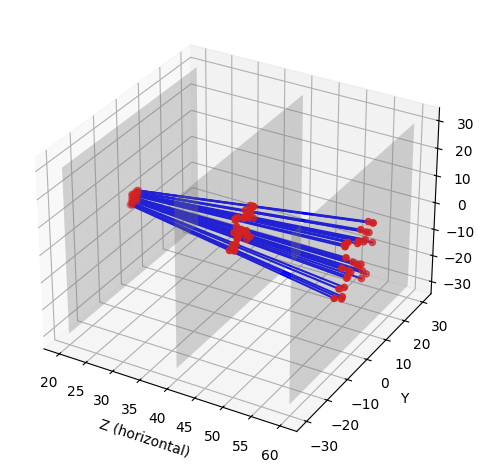


Plotting event tracks with ghost hits (false tracks)


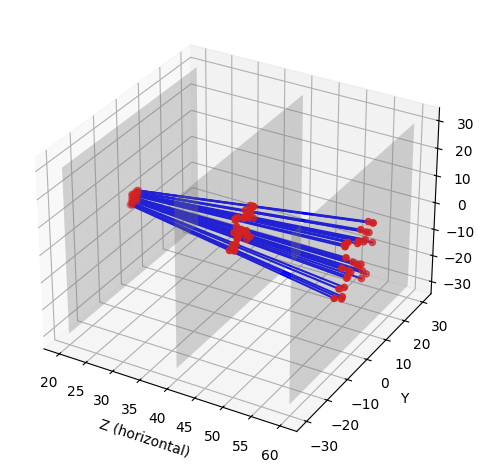

In [5]:
My_HHL.setup_events()

## Setup Hamiltonian

Shape of Hamiltonian matrix A: (2048, 2048)


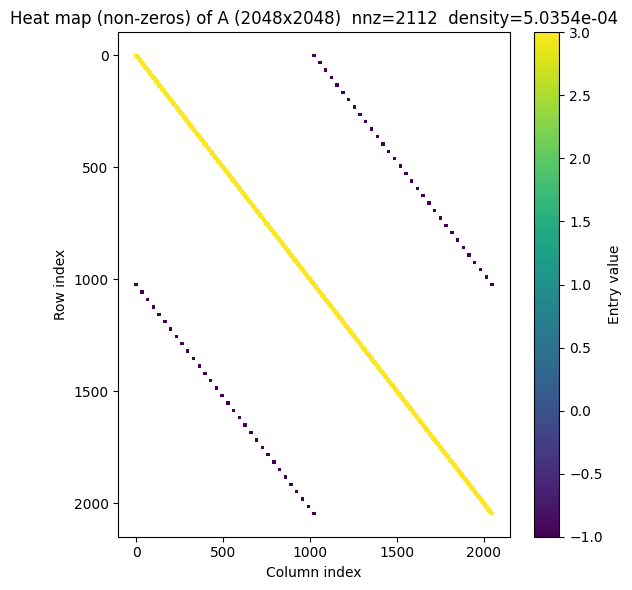

Eigenvalues of Hamiltonian matrix A:
[4. 2. 4. ... 3. 3. 3.]


In [6]:
My_HHL.setup_Hamiltonian()

## Run classical and 1-Bit HHL simulations

## References
### LHCb Velo Toy Model
- [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)
- [test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb)
- [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)
- [Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)
### Quantum Algorithms for Track Reconstruction
- [Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)
- [Quantum pathways for charged track finding in high-energy collisions, Front. Artif. Intell., 30 May 2024, Sec. Big Data and AI in High Energy Physics, Volume 7 - 2024](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1339785/full)
### Quantum Machine Learning in High Energy Physics
- [Wen Guan et al, Quantum machine learning in high energy physics, 2021 Mach. Learn.: Sci. Technol. 2 011003](https://quantum.web.cern.ch/sites/default/files/2021-07/Quantum%20Machine%20Learning%20in%20High%20Energy%20Physics.pdf)
- [Gray HM. Quantum pattern recognition algorithms for charged particle tracking. Philos Trans A Math Phys Eng Sci. 2022 Feb 7;380(2216):20210103. doi: 10.1098/rsta.2021.0103. Epub 2021 Dec 20. PMID: 34923843; PMCID: PMC8685607.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8685607/)
### Hough transform
- [Straight line Hough transform](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)
- [Frank Klefenz, Nico Wittrock, Frank Feldhoff, Parallel Quantum Hough Transform, 15 Nov 2023, arXiv:2311.09002 eess.IV](https://doi.org/10.48550/arXiv.2311.09002)
- [F. Klefenz, K.-H. Noffz, W. Conen, R. Zoz, A. Kugel, and R. Manner. “Track recognition in 4 µs by a systolic trigger processor using a parallel Hough transform”. IEEE Transactions on Nuclear Science 40, 688–691 (1993)](https://ieeexplore.ieee.org/document/256642)
### SQD_Alain
- [SQD_Alain](https://github.com/AlainChance/SQD_Alain)


--------------------------------------------------
 Solving classically using scipy.sparse.linalg.cg
--------------------------------------------------

Classical solution:
[0.5        0.33333333 0.33333333 ... 0.33333333 0.33333333 0.5       ]

Discretized classical solution:
[1 0 0 ... 0 0 1]

Correct indices of classical solution:
[0, 33, 66, 99, 132, 165, 198, 231, 264, 297, 330, 363, 396, 429, 462, 495, 528, 561, 594, 627, 660, 693, 726, 759, 792, 825, 858, 891, 924, 957, 990, 1023, 1024, 1057, 1090, 1123, 1156, 1189, 1222, 1255, 1288, 1321, 1354, 1387, 1420, 1453, 1486, 1519, 1552, 1585, 1618, 1651, 1684, 1717, 1750, 1783, 1816, 1849, 1882, 1915, 1948, 1981, 2014, 2047]

Displaying reconstructed event tracks from discretized classical solution

Track ID: 0
  Hit ID: 93, x: -1.0755998567953142, y: -1.3597840524342, z: 20, Module ID: 1
  Hit ID: 94, x: -3.2267995703859427, y: -4.0793521573025995, z: 40, Module ID: 2
  Hit ID: 95, x: -5.377999283976571, y: -6.798920262170999, z: 60

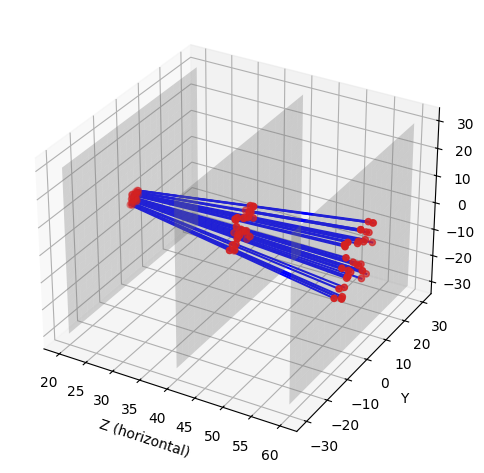


                  EVENT VALIDATION METRICS                  
Total Reconstructed Tracks:                             32
Total Truth Tracks:                                     32
Reconstruction Efficiency:                         100.00%
Ghost Rate:                                          0.00%
Clone Fraction:                           0.00% (0 clones)
Hit Efficiency:                                    100.00%
Purity:                                            100.00%


----------------------
 1-Bit HHL simulation
----------------------
class HHLAlgorithm modified by Alain Chancé
__init__ round(np.max(np.abs(np.linalg.eigvals(A)))): 4
__init__ self.t = np.pi / round(np.max(np.abs(np.linalg.eigvals(A)))): 0.7853981633974483

build_circuit - lam
0
2
4
6

Number of qubits in HHL circuit:  14
backend_name: AerSimulator noiseless

Using AerSimulator with method statevector and noiseless
Gate counts (w/ pre-init passes): OrderedDict({'ccx': 2480, 'crz': 244, 'u2': 18, 'h': 17, 'measure': 1

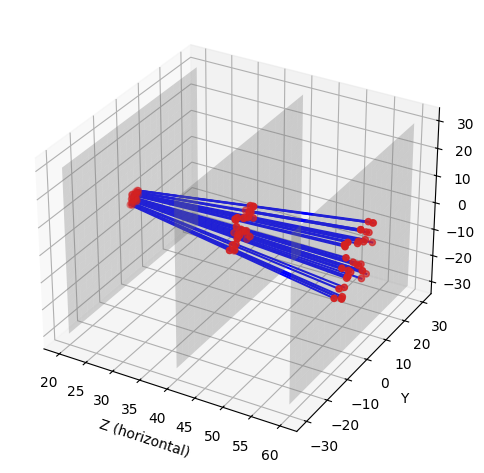

In [7]:
My_HHL.run_simulation()

## References
### LHCb Velo Toy Model
- [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)
- [test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb)
- [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)
### Algorithms for Track Reconstruction
- [Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)
- [Quantum pathways for charged track finding in high-energy collisions, Front. Artif. Intell., 30 May 2024, Sec. Big Data and AI in High Energy Physics, Volume 7 - 2024](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1339785/full)
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)
- [Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)
### Quantum Phase Estimation (QPE) Algorithm
- [Stefano Scali, Josh Kirsopp, Antonio Márquez Romero, Michał Krompiec, Spectral subspace extraction via incoherent quantum phase estimation, 16 Oct 2025, arXiv:2510.14744 quant-ph](
https://doi.org/10.48550/arXiv.2510.14744)
- [Antoine Lemelin, Christophe Pere, Olivier Landon-Cardinal, Camille Coti, Mid-circuit measurement as an algorithmic primitive, 2 Sep 2025, arXiv:2506.00118 quant-ph](
https://doi.org/10.48550/arXiv.2506.00118) 
- [Phase estimation variants and its implication for quantum/classical architecture by Microsoft, From the need to hybridize algorithmically to the need to integrate QPUs with CPUs, J. Mikael, EDF, E. Vergnaud, Teratec TQCI, Conference on QPU/CPU Integration](https://www.teratec.eu/library/seminaires/2022/TQCI/Microsoft_Hybrid_QC_EDF.pdf)
- [quantum-phase-estimation.ipynb, Qiskit Textbook](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-phase-estimation.ipynb)
- [qiskit.circuit.library.phase_estimation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.phase_estimation)
- [Non-variational and Phase Estimation algorithms, Quantinuum's InQuanto 5.1.0](https://docs.quantinuum.com/inquanto/manual/algorithms/non_variational_overview.html)
### Simulated Bifurcation Algorithm
- [Simulated Bifurcation for Python](https://github.com/bqth29/simulated-bifurcation-algorithm/tree/main)
- [Hideki Okawa, Qing-Guo Zeng, Xian-Zhe Tao, Man-Hong Yung, Quantum-Annealing-Inspired Algorithms for Track Reconstruction at High-Energy Colliders, 30 Aug 2024, 	arXiv:2402.14718 quant-ph](https://doi.org/10.48550/arXiv.2402.14718)
### Quantum Machine Learning in High Energy Physics
- [Wen Guan et al, Quantum machine learning in high energy physics, 2021 Mach. Learn.: Sci. Technol. 2 011003](https://quantum.web.cern.ch/sites/default/files/2021-07/Quantum%20Machine%20Learning%20in%20High%20Energy%20Physics.pdf)
- [Gray HM. Quantum pattern recognition algorithms for charged particle tracking. Philos Trans A Math Phys Eng Sci. 2022 Feb 7;380(2216):20210103. doi: 10.1098/rsta.2021.0103. Epub 2021 Dec 20. PMID: 34923843; PMCID: PMC8685607.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8685607/)
### Hough transform
- [Straight line Hough transform](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)
- [Frank Klefenz, Nico Wittrock, Frank Feldhoff, Parallel Quantum Hough Transform, 15 Nov 2023, arXiv:2311.09002 eess.IV](https://doi.org/10.48550/arXiv.2311.09002)
- [F. Klefenz, K.-H. Noffz, W. Conen, R. Zoz, A. Kugel, and R. Manner. “Track recognition in 4 µs by a systolic trigger processor using a parallel Hough transform”. IEEE Transactions on Nuclear Science 40, 688–691 (1993)](https://ieeexplore.ieee.org/document/256642)
### SQD_Alain
- [SQD_Alain](https://github.com/AlainChance/SQD_Alain)